# Графовый анализ научных публикаций arXiv
## Контрфактические объяснения и алгоритмические рекомендации

Контрфактическое объяснение показывает, какие изменения объекта могут изменить решение модели. Algorithmic recourse рассматривает, насколько такие изменения доступны человеку.

Цель работы - собрать корпус публикаций, провести разведочный анализ, выделить ключевые слова, исследовать их граф и реализовать поиск близких публикаций.

| Пункт задания | Раздел |
|:--|:--|
| 1-2 | Выбор темы и сбор корпуса через arXiv API |
| 3 | Разведочный анализ и закон Ципфа |
| 4 | Нормализация и выделение ключевых слов |
| 5 | Граф ключевых слов |
| 6 | Кластеры и модульность |
| 7 | Центральности |
| 8-9 | Граф публикаций, поиск и тестирование |


## Подготовка среды

Файл data/arxiv_counterfactual_corpus.csv содержит ответ arXiv API. При обычном запуске используется этот файл. Чтобы заново обратиться к API, в разделе сбора данных нужно установить REFRESH_DATA = True.

Библиотеки: NumPy, pandas, Matplotlib, NetworkX, scikit-learn, NLTK. Для нормализации используется словарь WordNet.


In [1]:
from pathlib import Path
import re
import time
import urllib.error
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from functools import lru_cache
from itertools import combinations
from textwrap import fill

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score

RANDOM_STATE = 42
MIN_DATE = '2020-01-01'
MAX_DATE = '2026-09-19'
TOP_N_KEYWORDS = 12
DATA_PATH = Path('data') / 'arxiv_counterfactual_corpus.csv'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
pd.set_option('display.max_colwidth', 100)


## 1. Выбор темы и сбор корпуса — пункты 1–2

Тема работы — контрфактические объяснения и алгоритмические рекомендации. Это узкое направление объяснимого искусственного интеллекта.

Данные получены через официальный [arXiv API](https://info.arxiv.org/help/api/user-manual.html). В названии или аннотации ищутся фразы `counterfactual explanation`, `counterfactual explanations` и `algorithmic recourse`. Дата первой публикации ограничена периодом с 01.01.2020 по 19.09.2026.

Для каждой публикации сохраняются идентификатор, название, авторы, аннотация, дата, категории и ссылка. Загруженные записи дополнительно проверяются локально.


In [2]:
ARXIV_API = 'https://export.arxiv.org/api/query'
NS = {'atom': 'http://www.w3.org/2005/Atom',
      'open': 'http://a9.com/-/spec/opensearch/1.1/'}
SEARCH_QUERY = (
    '(ti:"counterfactual explanation" OR abs:"counterfactual explanation" OR '
    'ti:"counterfactual explanations" OR abs:"counterfactual explanations" OR '
    'ti:"algorithmic recourse" OR abs:"algorithmic recourse") AND '
    'submittedDate:[202001010000 TO 202609192359]'
)

def request_page(start, page_size=1000, attempts=3):
    params = {'search_query': SEARCH_QUERY, 'start': start, 'max_results': page_size,
              'sortBy': 'submittedDate', 'sortOrder': 'descending'}
    url = ARXIV_API + '?' + urllib.parse.urlencode(params)
    request = urllib.request.Request(url, headers={'User-Agent': 'counterfactual-graph-lab/1.0'})
    for attempt in range(attempts):
        try:
            with urllib.request.urlopen(request, timeout=90) as response:
                return response.read()
        except urllib.error.HTTPError as error:
            if error.code not in {429, 500, 502, 503, 504} or attempt == attempts - 1:
                raise
        except (urllib.error.URLError, TimeoutError):
            if attempt == attempts - 1:
                raise
        time.sleep(10 * (attempt + 1))

def parse_feed(xml_bytes):
    root = ET.fromstring(xml_bytes)
    records = []
    for entry in root.findall('atom:entry', NS):
        url = entry.findtext('atom:id', default='', namespaces=NS)
        paper_id = re.sub(r'v\d+$', '', url.split('/abs/')[-1])
        records.append({
            'id': paper_id,
            'title': ' '.join(entry.findtext('atom:title', default='', namespaces=NS).split()),
            'authors': [a.findtext('atom:name', default='', namespaces=NS)
                        for a in entry.findall('atom:author', NS)],
            'abstract': ' '.join(entry.findtext('atom:summary', default='', namespaces=NS).split()),
            'published': entry.findtext('atom:published', default='', namespaces=NS)[:10],
            'categories': [c.attrib['term'] for c in entry.findall('atom:category', NS)],
            'url': f'https://arxiv.org/abs/{paper_id}'
        })
    total = int(root.findtext('open:totalResults', default=str(len(records)), namespaces=NS))
    return records, total

def fetch_arxiv():
    records = []
    start = 0
    while True:
        if start:
            time.sleep(3)
        page, total = parse_feed(request_page(start))
        records.extend(page)
        start += len(page)
        print(f'Загружено {start} из {total}')
        if start >= total or not page:
            break
    return pd.DataFrame(records)


In [3]:
REFRESH_DATA = False

if REFRESH_DATA:
    raw_corpus = fetch_arxiv()
    saved = raw_corpus.copy()
    saved['authors'] = saved['authors'].map(lambda values: '; '.join(values))
    saved['categories'] = saved['categories'].map(lambda values: ', '.join(values))
    DATA_PATH.parent.mkdir(exist_ok=True)
    saved.to_csv(DATA_PATH, index=False, encoding='utf-8-sig')
else:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f'Не найден файл {DATA_PATH}')
    raw_corpus = pd.read_csv(DATA_PATH, dtype={'id': str})
    raw_corpus['authors'] = raw_corpus['authors'].map(lambda value: value.split('; '))
    raw_corpus['categories'] = raw_corpus['categories'].map(lambda value: value.split(', '))

corpus = raw_corpus.drop_duplicates('id').copy()
corpus['published'] = pd.to_datetime(corpus['published'], errors='coerce')
topic_pattern = r'\bcounterfactual\s+explanations?\b|\balgorithmic\s+recourse\b'
topic_text = (corpus['title'] + ' ' + corpus['abstract']).str.lower().str.replace('-', ' ', regex=False)
valid = (
    corpus['published'].between(MIN_DATE, MAX_DATE)
    & corpus['title'].str.strip().ne('')
    & corpus['abstract'].str.strip().ne('')
    & corpus['authors'].map(lambda values: bool(values) and all(value.strip() for value in values))
    & topic_text.str.contains(topic_pattern, regex=True)
)
rejected = corpus.loc[~valid, ['id', 'title']]
corpus = corpus.loc[valid].sort_values(['published', 'id'], ascending=False).reset_index(drop=True)
corpus['year'] = corpus['published'].dt.year
corpus['text'] = corpus['title'] + '. ' + corpus['abstract']

assert len(corpus) >= 300
assert corpus['id'].is_unique
assert corpus['published'].between(MIN_DATE, MAX_DATE).all()
assert corpus[['id', 'title', 'abstract', 'published']].notna().all().all()

print(f'Получено записей: {len(raw_corpus)}. После проверки: {len(corpus)}. Исключено: {len(rejected)}.')
print('Диапазон дат:', corpus['published'].min().date(), '—', corpus['published'].max().date())
display(corpus[['id', 'published', 'title', 'authors']].head(5))


Получено записей: 766. После проверки: 761. Исключено: 5.
Диапазон дат: 2020-01-21 — 2026-09-17


,id,published,title,authors
0,2609.20067,2026-09-17,FCA-Guided Counterfactual Explanations for Multi-Modal Breast Cancer Diagnosis: A Framework Achi...,"[Abdullahi Isa, Souley Boukari, Muhammad Aliyu]"
1,2609.19383,2026-09-16,FCx: An algorithm for finding Feasible Counterfactual Explanations,"[Kleopatra Markou, Vana Kalogeraki, Dimitrios Gunopulos]"
2,2609.18049,2026-09-16,Regional Explanations via Causal Sufficiency and Necessity,"[Xuexin Chen, Peng Liang, Zijian Li, Zhiyong Lin, Ruichu Cai]"
3,2609.13940,2026-09-12,"Optimal Transport for Efficient, Unsupervised Anomaly Detection on Industrial Data","[Abigail Langbridge, Fearghal O'Donncha, James T Rayfield, Bradley Eck]"
4,2609.12179,2026-09-10,Explanations-Driven Active Feature Acquisition for Algorithmic Recourse,"[Vinura Galwaduge, Jagath Samarabandu]"


В ответе API было 766 записей. После проверки осталось 761 уникальная публикация с 21.01.2020 по 17.09.2026. Пять записей исключены, поскольку локальная проверка не нашла заданные тематические фразы.

Корпус охватывает выдачу выбранного запроса, но не всю литературу по объяснимому ИИ: работы с другими формулировками могли не попасть в выборку.


## 3. Разведочный анализ — пункт 3

Проверяются пропуски, повторы, длины текстов, число авторов, распределения по годам
и категориям. Автор учитывается по строке имени из arXiv; однофамильцы и варианты
написания имени автоматически не разрешаются. Категории могут пересекаться.
Для подсчёта слов используются английские словоформы без удаления стоп-слов.

In [4]:
def words(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

corpus['title_words'] = corpus['title'].map(lambda text: len(words(text)))
corpus['abstract_words'] = corpus['abstract'].map(lambda text: len(words(text)))
corpus['author_count'] = corpus['authors'].map(len)
author_counts = Counter(author for authors in corpus['authors'] for author in authors)
category_counts = Counter(category for categories in corpus['categories'] for category in categories)
word_counts = Counter(word for text in corpus['text'] for word in words(text))

quality = pd.Series({
    'Публикаций': len(corpus),
    'Повторов ID': int(corpus['id'].duplicated().sum()),
    'Повторов названий': int(corpus['title'].str.casefold().duplicated().sum()),
    'Пропусков в обязательных полях': int(corpus[['title', 'abstract', 'published']].isna().sum().sum()),
    'Различных строк имён авторов': len(author_counts),
    'Словоупотреблений': sum(word_counts.values()),
    'Различных словоформ': len(word_counts)
}, name='Значение')
display(quality.to_frame())
display(corpus[['title_words', 'abstract_words', 'author_count']].describe().round(1))

,Значение
Публикаций,761
Повторов ID,0
Повторов названий,0
Пропусков в обязательных полях,0
Различных строк имён авторов,2138
Словоупотреблений,146067
Различных словоформ,7724


,title_words,abstract_words,author_count
count,761.0,761.0,761.0
mean,9.5,182.5,4.0
std,3.3,45.1,2.0
min,3.0,60.0,1.0
25%,7.0,150.0,3.0
50%,9.0,179.0,4.0
75%,11.0,217.0,5.0
max,27.0,302.0,27.0


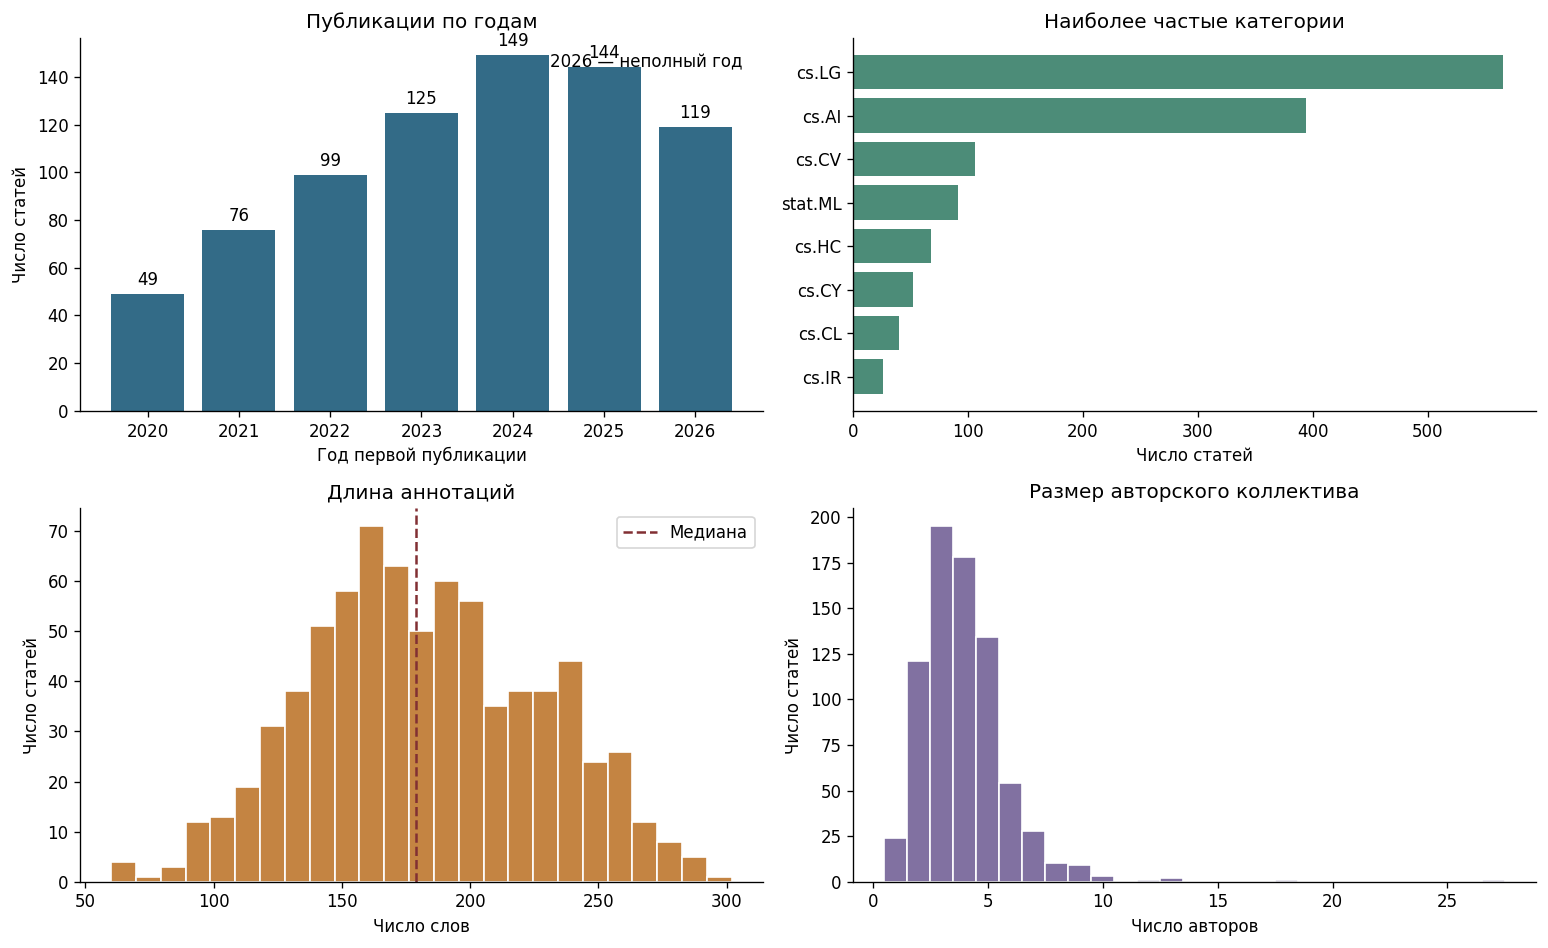

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
years = corpus['year'].value_counts().sort_index()
bars = axes[0, 0].bar(years.index.astype(str), years.values, color='#336b87')
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set(title='Публикации по годам', xlabel='Год первой публикации', ylabel='Число статей')
axes[0, 0].text(0.97, 0.92, '2026 — неполный год', ha='right', transform=axes[0, 0].transAxes)

top_categories = pd.Series(dict(category_counts.most_common(8))).sort_values()
axes[0, 1].barh(top_categories.index, top_categories.values, color='#4c8c78')
axes[0, 1].set(title='Наиболее частые категории', xlabel='Число статей')

axes[1, 0].hist(corpus['abstract_words'], bins=25, color='#c48442', edgecolor='white')
axes[1, 0].axvline(corpus['abstract_words'].median(), color='#812f33', linestyle='--', label='Медиана')
axes[1, 0].set(title='Длина аннотаций', xlabel='Число слов', ylabel='Число статей')
axes[1, 0].legend()

axes[1, 1].hist(corpus['author_count'], bins=np.arange(0.5, corpus['author_count'].max() + 1.5),
                color='#8171a1', edgecolor='white')
axes[1, 1].set(title='Размер авторского коллектива', xlabel='Число авторов', ylabel='Число статей')
plt.tight_layout()
plt.show()

В 2020 году в корпусе 49 публикаций, в 2024 — 149, в 2025 — 144. Для выбранного
запроса это указывает на увеличение числа работ по сравнению с началом периода.
В 2026 году найдено 119 статей, но данные заканчиваются сентябрём: сравнивать это
значение с полным 2025 годом как свидетельство спада нельзя. Вывод относится
к публикациям arXiv с заданными фразами, а не ко всей научной литературе.

Распределения длин текстов и числа авторов нужны для проверки неоднородности корпуса:
длинная аннотация даёт больше кандидатов в ключевые слова. В дальнейшем применяется
нормировка TF-IDF, а число тегов ограничивается. Сумма частот категорий превышает
число статей, поскольку одна работа может относиться к нескольким категориям.

### Проверка закона Ципфа

Для слов, упорядоченных по убыванию частоты, закон Ципфа задаёт зависимость
$f(r) \approx C r^{-s}$, где $r$ — ранг, а $s$ близок к единице.
На логарифмических осях ожидается приблизительно прямая с наклоном $-s$.
Здесь учитываются все словоформы названий и аннотаций, включая стоп-слова,
**до лемматизации**. Для сопоставления оцениваются наклоны на всём словаре и в
средней части распределения; диапазон рангов задаётся заранее.

,Диапазон,Наклон,s,R²,Слов
0,Весь словарь,-1.371,1.371,0.964,7724
1,Ранги 10–1000,-0.936,0.936,0.995,991


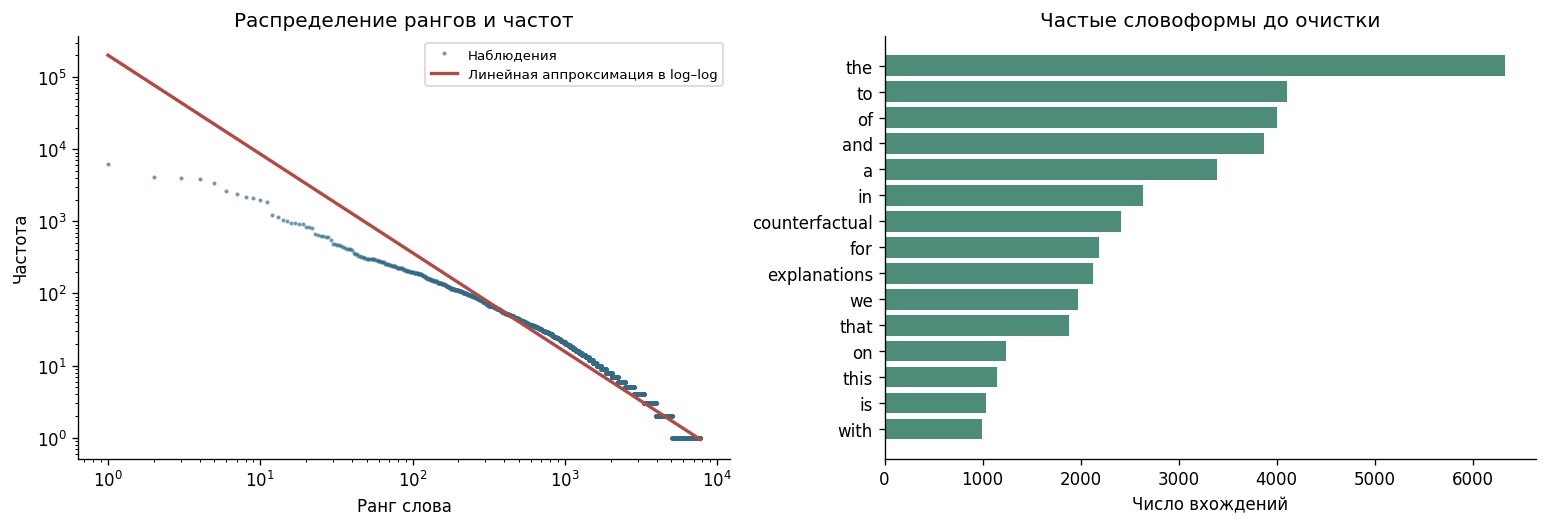

In [6]:
frequencies = np.array(sorted(word_counts.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)
zipf_rows = []
zipf_models = {}
for name, mask in {
    'Весь словарь': np.ones(len(ranks), dtype=bool),
    'Ранги 10–1000': (ranks >= 10) & (ranks <= 1000)
}.items():
    x = np.log10(ranks[mask]).reshape(-1, 1)
    y = np.log10(frequencies[mask])
    model = LinearRegression().fit(x, y)
    zipf_models[name] = model
    zipf_rows.append({'Диапазон': name, 'Наклон': model.coef_[0],
                      's': -model.coef_[0], 'R²': model.score(x, y), 'Слов': mask.sum()})
zipf_table = pd.DataFrame(zipf_rows)
display(zipf_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(ranks, frequencies, '.', ms=3, alpha=0.55, color='#336b87', label='Наблюдения')
fit = zipf_models['Весь словарь']
axes[0].loglog(ranks, 10 ** fit.predict(np.log10(ranks).reshape(-1, 1)),
               color='#b14a42', lw=2, label='Линейная аппроксимация в log–log')
axes[0].set(xlabel='Ранг слова', ylabel='Частота', title='Распределение рангов и частот')
axes[0].legend(fontsize=8)
top_words = pd.Series(dict(word_counts.most_common(15))).sort_values()
axes[1].barh(top_words.index, top_words.values, color='#4c8c78')
axes[1].set(title='Частые словоформы до очистки', xlabel='Число вхождений')
plt.tight_layout()
plt.show()

Частые служебные слова образуют начало распределения, а редкая терминология —
длинный хвост. Ступени в хвосте возникают из-за целочисленных частот, в том числе
слов с одним вхождением. Наклон и R² описывают приближение на указанных диапазонах.
Даже высокий R² в логарифмических координатах не доказывает степенной закон:
для строгой проверки потребовались бы отдельная статистическая модель хвоста
и сравнение с альтернативными распределениями. Здесь проверяется соответствие
характерной форме закона Ципфа.

### Проверка закона Хипса

Закон Хипса описывает рост словаря: $V(N)=kN^\beta$, где N — число
прочитанных словоупотреблений, V — число различных словоформ. Используются
те же токены до очистки, что и для Ципфа. Статьи перемешиваются с фиксированным
seed, чтобы ослабить влияние хронологического порядка. Аппроксимация выполняется
в log–log для N ≥ 1000; пять порядков позволяют оценить чувствительность β.
Сублинейный рост (0 < β < 1) соответствует форме закона; R² не доказывает закон.


,seed,β,k,R²
0,0,0.4967,21.8682,0.9941
1,7,0.4758,27.8550,0.9889
2,42,0.4979,21.6357,0.9936
3,99,0.5173,17.2997,0.9917
4,2026,0.4977,21.5163,0.9929


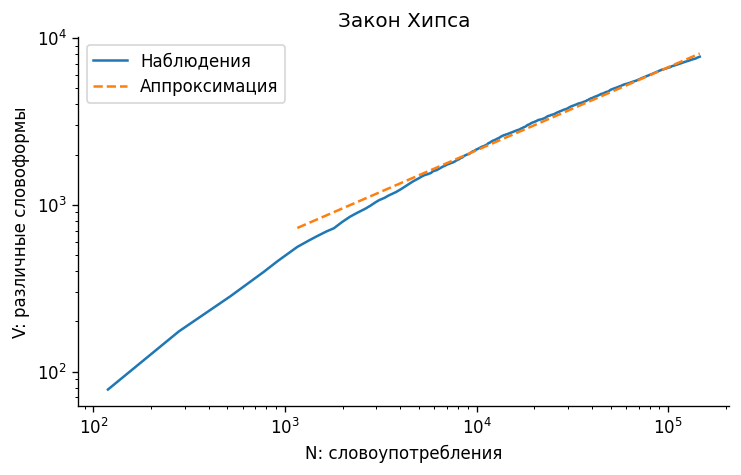

β при разных порядках: 0.476–0.517. Рост словаря сублинейный: новые слова появляются всё реже.


In [7]:
def heaps_curve(seed):
    vocabulary, ns, vs = set(), [], []
    count = 0
    for index in np.random.default_rng(seed).permutation(len(corpus)):
        tokens = words(corpus.iloc[index]['text'])
        count += len(tokens)
        vocabulary.update(tokens)
        ns.append(count)
        vs.append(len(vocabulary))
    return np.array(ns), np.array(vs)

heaps_rows = []
fig, ax = plt.subplots(figsize=(7, 4))
for seed in (0, 7, 42, 99, 2026):
    ns, vs = heaps_curve(seed)
    mask = ns >= 1000
    x, y = np.log10(ns[mask]).reshape(-1, 1), np.log10(vs[mask])
    fit = LinearRegression().fit(x, y)
    heaps_rows.append({'seed': seed, 'β': fit.coef_[0], 'k': 10 ** fit.intercept_, 'R²': fit.score(x, y)})
    if seed == RANDOM_STATE:
        ax.loglog(ns, vs, label='Наблюдения')
        ax.loglog(ns[mask], 10 ** fit.predict(x), '--', label='Аппроксимация')
heaps_table = pd.DataFrame(heaps_rows)
display(heaps_table.round(4))
ax.set(xlabel='N: словоупотребления', ylabel='V: различные словоформы', title='Закон Хипса')
ax.legend()
plt.show()
print(f"β при разных порядках: {heaps_table['β'].min():.3f}–{heaps_table['β'].max():.3f}. "
      'Рост словаря сублинейный: новые слова появляются всё реже.'
      if heaps_table['β'].between(0, 1, inclusive='neither').all() else 'Сублинейность не подтверждена.')


## 4. Ключевые слова — пункт 4

Единица анализа — **название + аннотация**. Текст переводится в нижний регистр. Существительные нормализуются с помощью **WordNetLemmatizer**: `models → model`, `responses → response`, `hypotheses → hypothesis`. Для специальных терминов и сокращений есть явные исключения: `bias`, `series`, `species` сохраняются; `gnns → gnn`, `llms → llm`, `ces → ce`. Это словарная нормализация существительных, а не полный морфологический разбор: глаголы и прилагательные могут сохранять разные формы.

Кандидаты — последовательные униграммы, биграммы и триграммы. Фразы не пересекают пунктуацию и не склеиваются через стоп-слова. Убираются URL, формулы между `$` и команды LaTeX; дефис разделяет слова.

К стандартному `ENGLISH_STOP_WORDS` вручную добавлены слова научного изложения: `paper`, `study`, `propose`, `present`, `method`, `result`, `using`, `used`, `based`, `show`, `approach`, `use`, `base`, `et`, `al` и перечисленные в коде варианты. Они часто описывают изложение и проведение исследования, а не его предмет. Это эвристический список, а не результат автоматического отбора. Проверяются как исходная форма, так и нормализованная. Тематические `counterfactual`, `explanation`, `recourse`, `causal` в список не добавляются; независимый фильтр `max_df` может исключить чрезмерно частую фразу.

TF-IDF использует `sublinear_tf=True`, `min_df=3`, `max_df=0.85` и L2-нормировку. Из 36 лучших кандидатов удаляются вложенные фразы, затем выбирается до 12 тегов. Так `neural network` и содержащая его `graph neural network` не увеличивают вес связи повторно в одной статье. Подписи показывают нормализованные теги.


In [8]:
stopwords = set(ENGLISH_STOP_WORDS) | {
    'paper', 'study', 'studies', 'propose', 'proposed', 'present', 'presented',
    'method', 'methods', 'result', 'results', 'using', 'used', 'based',
    'show', 'shows', 'approach', 'approaches', 'use', 'uses', 'base', 'et', 'al'
}
# WordNet содержит словарные правила морфологии, а не только обрезание окончаний.
try:
    wordnet.ensure_loaded()
except LookupError:
    if not nltk.download('wordnet', quiet=True):
        raise RuntimeError('Установите WordNet: python -m nltk.downloader wordnet')
    wordnet.ensure_loaded()
lemmatizer = WordNetLemmatizer()
# Сохраняем специальные термины; сокращения нормализуем отдельно.
singular_forms = {'series':'series', 'species':'species', 'bias':'bias',
                  'gnns':'gnn', 'llms':'llm', 'ces':'ce', 'cfes':'cfe',
                  'vces':'vce', 'cfs':'cf', 'counterfactuals':'counterfactual',
                  'explainers':'explainer'}
@lru_cache(maxsize=None)
def lemma_word(word):
    return singular_forms.get(word, lemmatizer.lemmatize(word, pos='n'))

def candidate_terms(text):
    text=re.sub(r'https?://\S+','.',text.lower()); text=re.sub(r'\$[^$]*\$','.',text); text=re.sub(r'\\[a-z]+','.',text)
    for fragment in re.split(r'[^a-z\s]+',text.replace('-',' ')):
        tokens=fragment.split()
        for size in (1,2,3):
            for start in range(len(tokens)-size+1):
                phrase=tokens[start:start+size]; normalized=[lemma_word(word) for word in phrase]
                if all((len(w)>=3 or w in {'ai','ml','rl'}) and w not in stopwords and n not in stopwords for w,n in zip(phrase,normalized)):
                    yield ' '.join(normalized),' '.join(phrase)
def extract_terms(text): return [term for term,surface in candidate_terms(text)]
def is_nested(short,long): return short!=long and f' {short} ' in f' {long} '
def select_keywords(row,terms,top_n=TOP_N_KEYWORDS):
    ranked=sorted(zip(row.indices,row.data),key=lambda pair:(-pair[1],terms[pair[0]])); candidates=[terms[i] for i,score in ranked[:3*top_n]]
    return [term for term in candidates if not any(is_nested(term,other) for other in candidates)][:top_n]
for plural, singular in {'explanations':'explanation', 'analyses':'analysis',
                         'models':'model', 'gnns':'gnn', 'llms':'llm',
                         'cases':'case', 'responses':'response',
                         'hypotheses':'hypothesis', 'classes':'class'}.items():
    assert lemma_word(plural) == singular
for term in ('bias', 'series', 'species', 'analysis'):
    assert lemma_word(term) == term
assert 'neural network' not in extract_terms('Neural. Network')
assert 'neural network' not in extract_terms('Neural and network')
assert not is_nested('age', 'agent')
print('Проверки нормализации пройдены: регулярные и нерегулярные формы, исключения и сокращения.')


Проверки нормализации пройдены: регулярные и нерегулярные формы, исключения и сокращения.


Размер матрицы TF-IDF: (761, 4549)
Различных выбранных тегов: 3597
Тегов на статью: от 12 до 12


,Лемма,Ключевое слово,Статей
0,llm,llm,20
1,gnn,gnn,19
2,robustness,robustness,17
3,cfe,cfe,17
4,algorithmic recourse,algorithmic recourse,16
5,ce,ce,16
6,ml,ml,15
7,xai,xai,15
8,cf,cf,14
9,action,action,14


,id,title,keywords
0,2609.20067,FCA-Guided Counterfactual Explanations for Multi-Modal Breast Cancer Diagnosis: A Framework Achieving Perfect Validity with Emergent Sparsity,"multi modal, guided counterfactual, breast, perfect validity, cancer, sparsity, nice, clinically, diagnosis, achieves, best, evaluated"
1,2609.19383,FCx: An algorithm for finding Feasible Counterfactual Explanations,"guaranteeing, feasible counterfactual explanation, cf, low cost, feasibility, absolute, efficiently generate, lof, enforces, explanation identify, inferred, job"
100,2601.22653,Human-Centered Explainability in AI-Enhanced UI Security Interfaces: Designing Trustworthy Copilots for Cybersecurity Analysts,"analyst, security, cybersecurity, human centered, style, design, explainability, controlled user, explanation strategy, guideline, triage, user interface"
300,2409.09461,TX-Gen: Multi-Objective Optimization for Sparse Counterfactual Explanations for Time-Series Classification,"time series classification, multi objective optimization, generating counterfactual explanation, benchmark datasets demonstrate, change model, dominated, generating high quality, original time series, promising solution, understanding model, evolutionary, time series model"
600,2205.15406,From Explanation to Recommendation: Ethical Standards for Algorithmic Recourse,"ethical, purpose, algorithmic recourse, capability, standard, contest, traction, allowing user, explanation problem, gaining, viewed, recommendation"


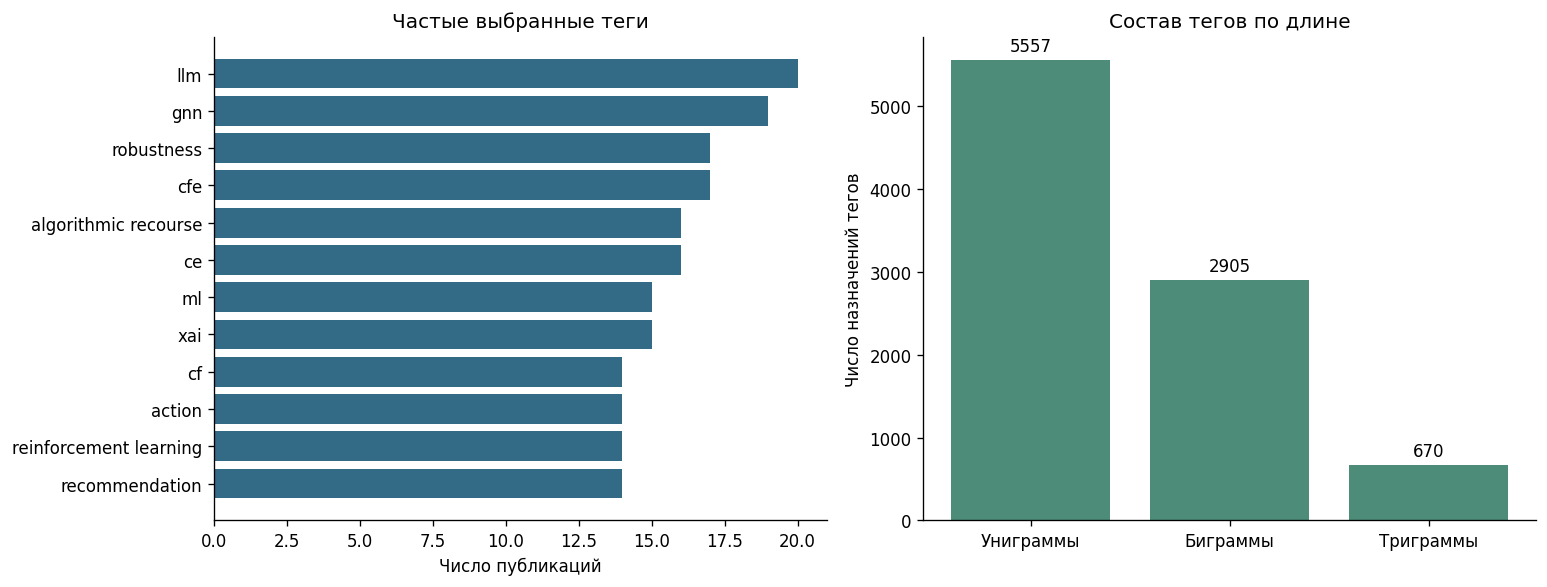

In [9]:
vectorizer = TfidfVectorizer(analyzer=extract_terms, min_df=3, max_df=0.85, sublinear_tf=True)
tfidf = vectorizer.fit_transform(corpus['text'])
terms = np.array(vectorizer.get_feature_names_out())
corpus['keywords'] = [select_keywords(row, terms) for row in tfidf]

forms = defaultdict(Counter)
for text in corpus['text']:
    for term, surface in candidate_terms(text):
        forms[term][surface] += 1
labels = {term: term for term in forms}
keyword_counts = Counter(term for tags in corpus['keywords'] for term in set(tags))

assert corpus['keywords'].map(bool).all()
assert all(len(tags) == len(set(tags)) for tags in corpus['keywords'])
assert all(not any(is_nested(a, b) or is_nested(b, a) for a, b in combinations(tags, 2))
           for tags in corpus['keywords'])

print('Размер матрицы TF-IDF:', tfidf.shape)
print('Различных выбранных тегов:', len(keyword_counts))
print('Тегов на статью: от', corpus['keywords'].map(len).min(), 'до', corpus['keywords'].map(len).max())
keyword_table = pd.DataFrame([
    {'Лемма': term, 'Ключевое слово': labels[term], 'Статей': count}
    for term, count in keyword_counts.most_common(20)
])
display(keyword_table)
examples = corpus.loc[[0, 1, 100, 300, 600], ['id', 'title', 'keywords']].copy()
examples['keywords'] = examples['keywords'].map(lambda tags: ', '.join(labels[t] for t in tags))
with pd.option_context('display.max_colwidth', None):
    display(examples)

sizes = Counter(len(term.split()) for tags in corpus['keywords'] for term in tags)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top = keyword_table.head(12).iloc[::-1]
axes[0].barh(top['Ключевое слово'], top['Статей'], color='#336b87')
axes[0].set(title='Частые выбранные теги', xlabel='Число публикаций')
bars = axes[1].bar(['Униграммы', 'Биграммы', 'Триграммы'], [sizes[n] for n in (1, 2, 3)], color='#4c8c78')
axes[1].bar_label(bars, padding=3)
axes[1].set(title='Состав тегов по длине', ylabel='Число назначений тегов')
plt.tight_layout()
plt.show()

TF-IDF выделяет выражения, характерные для отдельных работ относительно этого
корпуса. Частота в таблице — число публикаций, где выражение выбрано тегом;
она отличается от числа его вхождений в исходные тексты.

Нормализация объединяет грамматические варианты, но не все синонимы и сокращения:
`gnn` и `graph neural network`, например, могут остаться разными вершинами.
Статистическая биграмма или триграмма не обязательно является устойчивым термином.
Поэтому ниже кластеры рассматриваются вместе с названиями и аннотациями
представляющих их статей, а качество поиска дополнительно проверяется вручную.

## 5. Граф ключевых слов — пункт 5

Вершина — нормализованное ключевое слово. Два слова связаны, если они выбраны
тегами хотя бы одной общей публикации. Вес равен числу таких публикаций:

$$w_{ij}=\sum_{d=1}^{N} \mathbf{1}(i\in K_d)\mathbf{1}(j\in K_d), \qquad i\ne j.$$

Повторы слова внутри одной статьи не увеличивают вес. Петли не создаются.
Основной анализ проводится на полном графе: пороги веса рассматриваются
отдельно, чтобы не получить искусственно высокую модульность после распада
графа на множество небольших компонент.

In [10]:
keyword_graph = nx.Graph()
keyword_graph.add_nodes_from(sorted(keyword_counts))
for tags in corpus['keywords']:
    for left, right in combinations(sorted(set(tags)), 2):
        if keyword_graph.has_edge(left, right):
            keyword_graph[left][right]['weight'] += 1
        else:
            keyword_graph.add_edge(left, right, weight=1)
for node in keyword_graph:
    keyword_graph.nodes[node]['label'] = labels[node]
    keyword_graph.nodes[node]['document_frequency'] = keyword_counts[node]
for left, right, edge in keyword_graph.edges(data=True):
    edge['distance'] = 1 / edge['weight']

keyword_components = list(nx.connected_components(keyword_graph))
display(pd.Series({
    'Вершины': keyword_graph.number_of_nodes(), 'Рёбра': keyword_graph.number_of_edges(),
    'Компоненты связности': len(keyword_components),
    'Крупнейшая компонента': max(map(len, keyword_components)),
    'Плотность': nx.density(keyword_graph),
    'Средняя степень': np.mean([degree for node, degree in keyword_graph.degree()])
}, name='Значение').to_frame())
assert nx.number_of_selfloops(keyword_graph) == 0

,Значение
Вершины,3597.000000
Рёбра,49404.000000
Компоненты связности,1.000000
Крупнейшая компонента,3597.000000
Плотность,0.007639
Средняя степень,27.469558


## 6. Кластеры ключевых слов — пункт 6

Для взвешенного графа применяется Louvain с `resolution=1` и фиксированным
`seed=42`. Алгоритм ищет разбиение с высокой модульностью — избытком связей
внутри сообществ относительно модели с теми же взвешенными степенями.
Найденное разбиение не обязано быть единственным или глобально оптимальным.
Модульность не является долей правильно классифицированных слов.

Кластеры нумеруются по убыванию размера. Для интерпретации выводятся частые теги
каждого кластера и две статьи с максимальным числом его тегов.

In [11]:
communities = nx.community.louvain_communities(keyword_graph, weight='weight', seed=RANDOM_STATE)
communities = sorted(communities, key=lambda group: (-len(group), sorted(group)[0]))
partition = {word: i + 1 for i, group in enumerate(communities) for word in sorted(group)}
modularity = nx.community.modularity(keyword_graph, communities, weight='weight')
nx.set_node_attributes(keyword_graph, partition, 'community')

cluster_rows = []
cluster_examples = []
for number, group in enumerate(communities, start=1):
    top = sorted(group, key=lambda word: (-keyword_counts[word], word))[:10]
    cluster_rows.append({'Кластер': number, 'Слов': len(group),
                         'Частые теги': ', '.join(labels[word] for word in top)})
    overlaps = corpus['keywords'].map(lambda tags: len(set(tags) & group))
    for index in overlaps.nlargest(2).index:
        cluster_examples.append({'Кластер': number, 'Общих тегов': int(overlaps[index]),
                                 'id': corpus.at[index, 'id'], 'Статья': corpus.at[index, 'title']})
cluster_table = pd.DataFrame(cluster_rows)
cluster_example_table = pd.DataFrame(cluster_examples)
print(f'Кластеров: {len(communities)}. Модульность полного графа: {modularity:.4f}.')
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(cluster_table)
    display(cluster_example_table)


Кластеров: 24. Модульность полного графа: 0.3646.


,Кластер,Слов,Частые теги
0,1,246,"path, visual counterfactual explanation, black box model, rule, control, condition, discrete, map, vce, obtain"
1,2,241,"llm, large language model, edits, end user, feature attribution, preference, consistency, prompt, technical, contextual"
2,3,234,"algorithmic recourse, counterfactual example, fairness, ml model, environment, tabular data, anomalous, argumentation, counterfactual explainability, necessary"
3,4,210,"cfe, cf, temporal, intervention, attack, inference, interaction, definition, end, game"
4,5,191,"query, region, guided, label, relevance, aware, document, formulation, ranking, adversarial example"
5,6,190,"multivariate time series, score, sparsity, counterfactual image, deep learning, effort, lot, salient, time series data, trajectory"
6,7,190,"recommendation, event, causal relationship, anomaly detection, causal graph, personalized, realistic counterfactual explanation, subset, analytics, causality"
7,8,182,"attribute, concept, image, factor, sparse, adversarial attack, general, latent, reasoning, shap"
8,9,178,"latent space, plausibility, generative model, probabilistic, distance, fair, time series, model agnostic, causal algorithmic recourse, computationally expensive"
9,10,159,"diffusion, attribution, detection, diagnosis, information, interpretation, assessment, disease, object, explainable ai"


,Кластер,Общих тегов,id,Статья
0,1,12,2410.22615,CoGS: Model Agnostic Causality Constrained Counterfactual Explanations using goal-directed ASP
1,1,12,2405.18293,CF-OPT: Counterfactual Explanations for Structured Prediction
2,2,12,2507.15162,Designing User-Centric Metrics for Evaluation of Counterfactual Explanations
3,2,12,2503.18185,Exploring Energy Landscapes for Minimal Counterfactual Explanations: Applications in Cybersecurity and Beyond
4,3,12,2605.31272,Algorithmic Recourse of In-Context Learning for Tabular Data
5,3,12,2603.11140,Procedural Fairness via Group Counterfactual Explanation
6,4,12,2602.03611,Explanations Leak: Membership Inference with Differential Privacy and Active Learning Defense
7,4,12,2507.05541,SenseCF: LLM-Prompted Counterfactuals for Intervention and Sensor Data Augmentation
8,5,12,2508.03606,Demystifying Sequential Recommendations: Counterfactual Explanations via Genetic Algorithms
9,5,12,2505.21330,UGCE: User-Guided Incremental Counterfactual Exploration


In [12]:
stability_rows = []
node_order = sorted(keyword_graph)
reference = [partition[node] for node in node_order]
for seed in (0, 7, 42, 99, 2026):
    groups = nx.community.louvain_communities(keyword_graph, weight='weight', seed=seed)
    membership = {word: i for i, group in enumerate(groups) for word in group}
    stability_rows.append({
        'seed': seed, 'Кластеров': len(groups),
        'Модульность': nx.community.modularity(keyword_graph, groups, weight='weight'),
        'ARI относительно seed=42': adjusted_rand_score(reference, [membership[n] for n in node_order])
    })
stability_table = pd.DataFrame(stability_rows)
display(stability_table.round(3))

threshold_rows = []
for threshold in (1, 2, 3):
    graph = keyword_graph.copy()
    graph.remove_edges_from([(a, b) for a, b, edge in graph.edges(data=True) if edge['weight'] < threshold])
    if threshold > 1:
        graph.remove_nodes_from(list(nx.isolates(graph)))
    groups = nx.community.louvain_communities(graph, weight='weight', seed=RANDOM_STATE)
    components = list(nx.connected_components(graph))
    threshold_rows.append({
        'Минимальный вес': threshold, 'Вершин': len(graph), 'Рёбер': graph.number_of_edges(),
        'Компонент': len(components), 'Крупнейшая компонента': max(map(len, components), default=0),
        'Модульность': nx.community.modularity(graph, groups, weight='weight') if graph.number_of_edges() else np.nan
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

,seed,Кластеров,Модульность,ARI относительно seed=42
0,0,29,0.367,0.152
1,7,27,0.368,0.123
2,42,24,0.365,1.000
3,99,27,0.367,0.137
4,2026,26,0.366,0.120


,Минимальный вес,Вершин,Рёбер,Компонент,Крупнейшая компонента,Модульность
0,1,3597,49404,1,3597,0.365
1,2,677,741,167,52,0.966
2,3,66,61,23,8,0.883


### Интерпретация 24 сообществ ключевых слов

При `seed=42` на полном графе получено **24 сообщества**, модульность **0.3646** (таблица выше). Номера ниже относятся к этому конкретному разбиению. Теги перечислены по таблице, а названия статей проверены по таблице примеров. Связь возникает потому, что теги совместно выбраны у публикаций, а не потому, что алгоритм понимает их смысл. Название сообщества — осторожная интерпретация преобладающих тегов; оно не обязано описывать каждую вершину.

| № | Интерпретация и основание |
|---:|---|
| 1 | **Структура и ограничения контрфактов, смешанная группа.** `path`, `rule`, `control`, `condition` описывают допустимый путь изменения признаков; `visual counterfactual explanation` и `black box model` относятся к другим постановкам. Статья *CoGS* иллюстрирует правила и поиск пути, но не всю визуальную часть группы. |
| 2 | **Языковые модели и взаимодействие с пользователем.** `llm`, `large language model`, `prompt` образуют явную тему; `end user` и `preference` связывают её с оценкой объяснений человеком. Статья *Designing User-Centric Metrics for Evaluation of Counterfactual Explanations* показывает пользовательскую часть, но сама по себе не доказывает, что все работы группы посвящены LLM. |
| 3 | **Алгоритмические рекомендации и справедливость.** `algorithmic recourse`, `fairness`, `tabular data`, `ml model` связывают изменение решения классификатора с его последствиями для групп. Примеры *Algorithmic Recourse of In-Context Learning for Tabular Data* и *Procedural Fairness via Group Counterfactual Explanation* отражают две стороны сообщества. |
| 4 | **Разнородные применения контрфактов.** `cfe`, `cf` — общие сокращения; `temporal`, `intervention`, `attack`, `inference` расходятся по задачам. Статьи об утечке данных и о сенсорных вмешательствах подтверждают смешанный характер, поэтому узкую тему группе приписывать нельзя. |
| 5 | **Запросы и исследование альтернатив.** `query`, `region`, `guided`, `relevance`, `ranking` описывают поиск и отбор результатов. Статья о последовательных рекомендациях показывает применение к ранжированию, а *UGCE* — управляемое пользователем исследование вариантов. |
| 6 | **Временные ряды и компактные изменения.** `multivariate time series`, `time series data`, `trajectory` относятся к последовательным данным; `sparsity`, `score` — к оценке и ограничению изменений. Первая статья в таблице непосредственно посвящена объяснениям классификации многомерных временных рядов. `counterfactual image` показывает, что группа не исключительно временная. |
| 7 | **Причинность и персонализация, смешанная группа.** `causal relationship`, `causal graph`, `causality` отражают поиск причинных связей; `recommendation`, `personalized`, `analytics` — прикладное использование. Статья о персонализированном обучении иллюстрирует пересечение этих тем, а пример про Shapley value — неоднородность группы. |
| 8 | **Признаки и визуальные представления.** `attribute`, `concept`, `image`, `factor`, `latent` описывают факторы, изменяемые в объяснении; `adversarial attack` добавляет смежную задачу. *Cross-modal Counterfactual Explanations* иллюстрирует визуальное направление, но второй пример относится к временным рядам. |
| 9 | **Генеративная правдоподобность контрфактов.** `latent space`, `plausibility`, `generative model`, `probabilistic`, `distance` связывают поиск альтернатив со скрытым представлением и оценкой реалистичности. Пример *GenFacts* применяет генерацию к временным рядам; тема сообщества шире этого приложения. |
| 10 | **Диффузия и медицинские объяснения.** `diffusion`, `detection`, `diagnosis`, `disease`, `attribution` соединяют генеративный метод и интерпретацию медицинских данных. *DreaMR* показывает объяснение для fMRI, второй пример — медицинское исследование; общие теги `information` и `assessment` делают границы группы нечёткими. |
| 11 | **Выполнимость при неопределённости.** `feasibility`, `uncertainty`, `gaussian`, `distribution` указывают на ограничения и вероятностные оценки; `bias` и `clustering` расширяют состав. *P²CE* относится к правдоподобным альтернативам, а статья о Gaussian process auto-encoder — к вероятностной модели. |
| 12 | **Классификаторы и ограничения объяснений.** `decision boundary`, `classifier`, `constraint`, `feature space`, `risk` объединены задачей поиска изменения признаков относительно границы решения. Статья об оценке методов на неполных входах показывает одну постановку; пример про морфологию галактик — прикладную ветвь. |
| 13 | **Робастность к изменению модели.** `robustness`, `guarantee`, `model change`, `bayesian`, `ensemble` связывают устойчивость объяснения и неопределённость модели. Вторая статья примеров прямо исследует вероятностные гарантии при изменении модели; первая посвящена ограничениям post-hoc объяснений. |
| 14 | **Представления и качество предсказания, смешанная группа.** `effect`, `predictive model`, `representation`, `signal`, `validity` слишком общие для узкой темы. Примеры о ложных корреляциях и многоцелевой генерации контрфактов относятся к разным вопросам; объединение следует трактовать осторожно. |
| 15 | **Взаимодействие и оспаривание решений.** `xai`, `feedback`, `question`, `answer`, `behavior` отражают коммуникацию объяснения пользователю. *Explainable AI Isn't Enough! Rethinking Algorithmic Contestability* показывает аспект оспаривания, а пример про VQA — объяснение ответа; это смежные, но разные применения. |
| 16 | **Графовые модели и динамические объяснения.** `gnn`, `graph neural network`, `edge`, `explainer`, `dynamic` задают графовую тематику. Пример про benchmark рекомендательных систем показывает, что статья с многими тегами группы может относиться к иной прикладной области; второй пример касается устойчивости в динамических данных. |
| 17 | **Общие объяснения и прикладные решения, смешанная группа.** `ce`, `ml`, `survey`, `interactive`, `business`, `case` — широкие понятия. Примеры о рекомендациях и уходе сотрудников используют контрфакты в разных задачах; отдельное узкое направление из этих тегов не следует. |
| 18 | **Планирование действий и обучение с подкреплением.** `action`, `reinforcement learning`, `sequence`, `plan`, `policy`, `agent` описывают последовательность действий для достижения альтернативного исхода. Оба примера статей — о контрфактических объяснениях действий и планов — поддерживают название группы. |
| 19 | **Возмущения и доступ к модели.** `perturbation`, `gradient`, `surrogate model`, `input perturbation`, `inversion` связывают генерацию изменений с использованием заменяющей модели или восстановлением классификатора. Пример *Classifier Reconstruction Through Counterfactual-Aware Wasserstein Prototypes* показывает ветвь реконструкции; второй — прогнозирование временных рядов. |
| 20 | **Локальные объяснения и доверие пользователя.** `local`, `trust`, `feature importance`, `accept`, `communication` связывают объяснение конкретного решения с его восприятием. *TIGTEC* иллюстрирует важность токенов для текстового контрфакта, второй пример — объяснение уверенности модели. |
| 21 | **Разнообразие и стоимость контрфактов.** `diversity`, `cost`, `acceptance`, `local explanation` выражают критерии отбора нескольких полезных альтернатив. Статья *AVCG* посвящена генерации при распределениях гипотез; `customer` и `concept drift` показывают смешение прикладных контекстов. |
| 22 | **Сравнение альтернатив и критерии выбора.** `criterion`, `counterfactual reasoning`, `item`, `change necessary` связывают сравнение объектов с вопросом, какое изменение нужно для другого результата. Примеры о сравнительных объяснениях рекомендаций и k-NN отражают разные применения этой идеи. |
| 23 | **Медицинские и молекулярные применения.** `patient`, `covid`, `molecular`, `modeling`, `workflow` объединяют предметную область здоровья, но молекулы и пациенты — разные уровни анализа. Оба выбранных примера посвящены молекулярным контрфактам, поэтому они не представляют весь кластер. |
| 24 | **Приватность контрфактического поиска.** `privacy`, `user`, `database`, `private information`, `favourable outcome` связывают получение альтернативного исхода с защитой пользовательских данных. Оба примера *Private Counterfactual Retrieval* непосредственно поддерживают эту интерпретацию. |

**Качество и устойчивость.** При пяти seed модульность составляет 0.365–0.368, но ARI других запусков относительно `seed=42` лишь 0.120–0.152: сходное значение модульности не означает одинаковый состав сообществ. При пороге веса 2 модульность 0.966 достигается уже на фрагментированном графе (677 вершин, 167 компонент, крупнейшая — 52 вершины), поэтому интерпретация основана на полном графе. Показанный ниже рисунок содержит только до двух вершин из каждого кластера; полный состав дан в таблице выше.


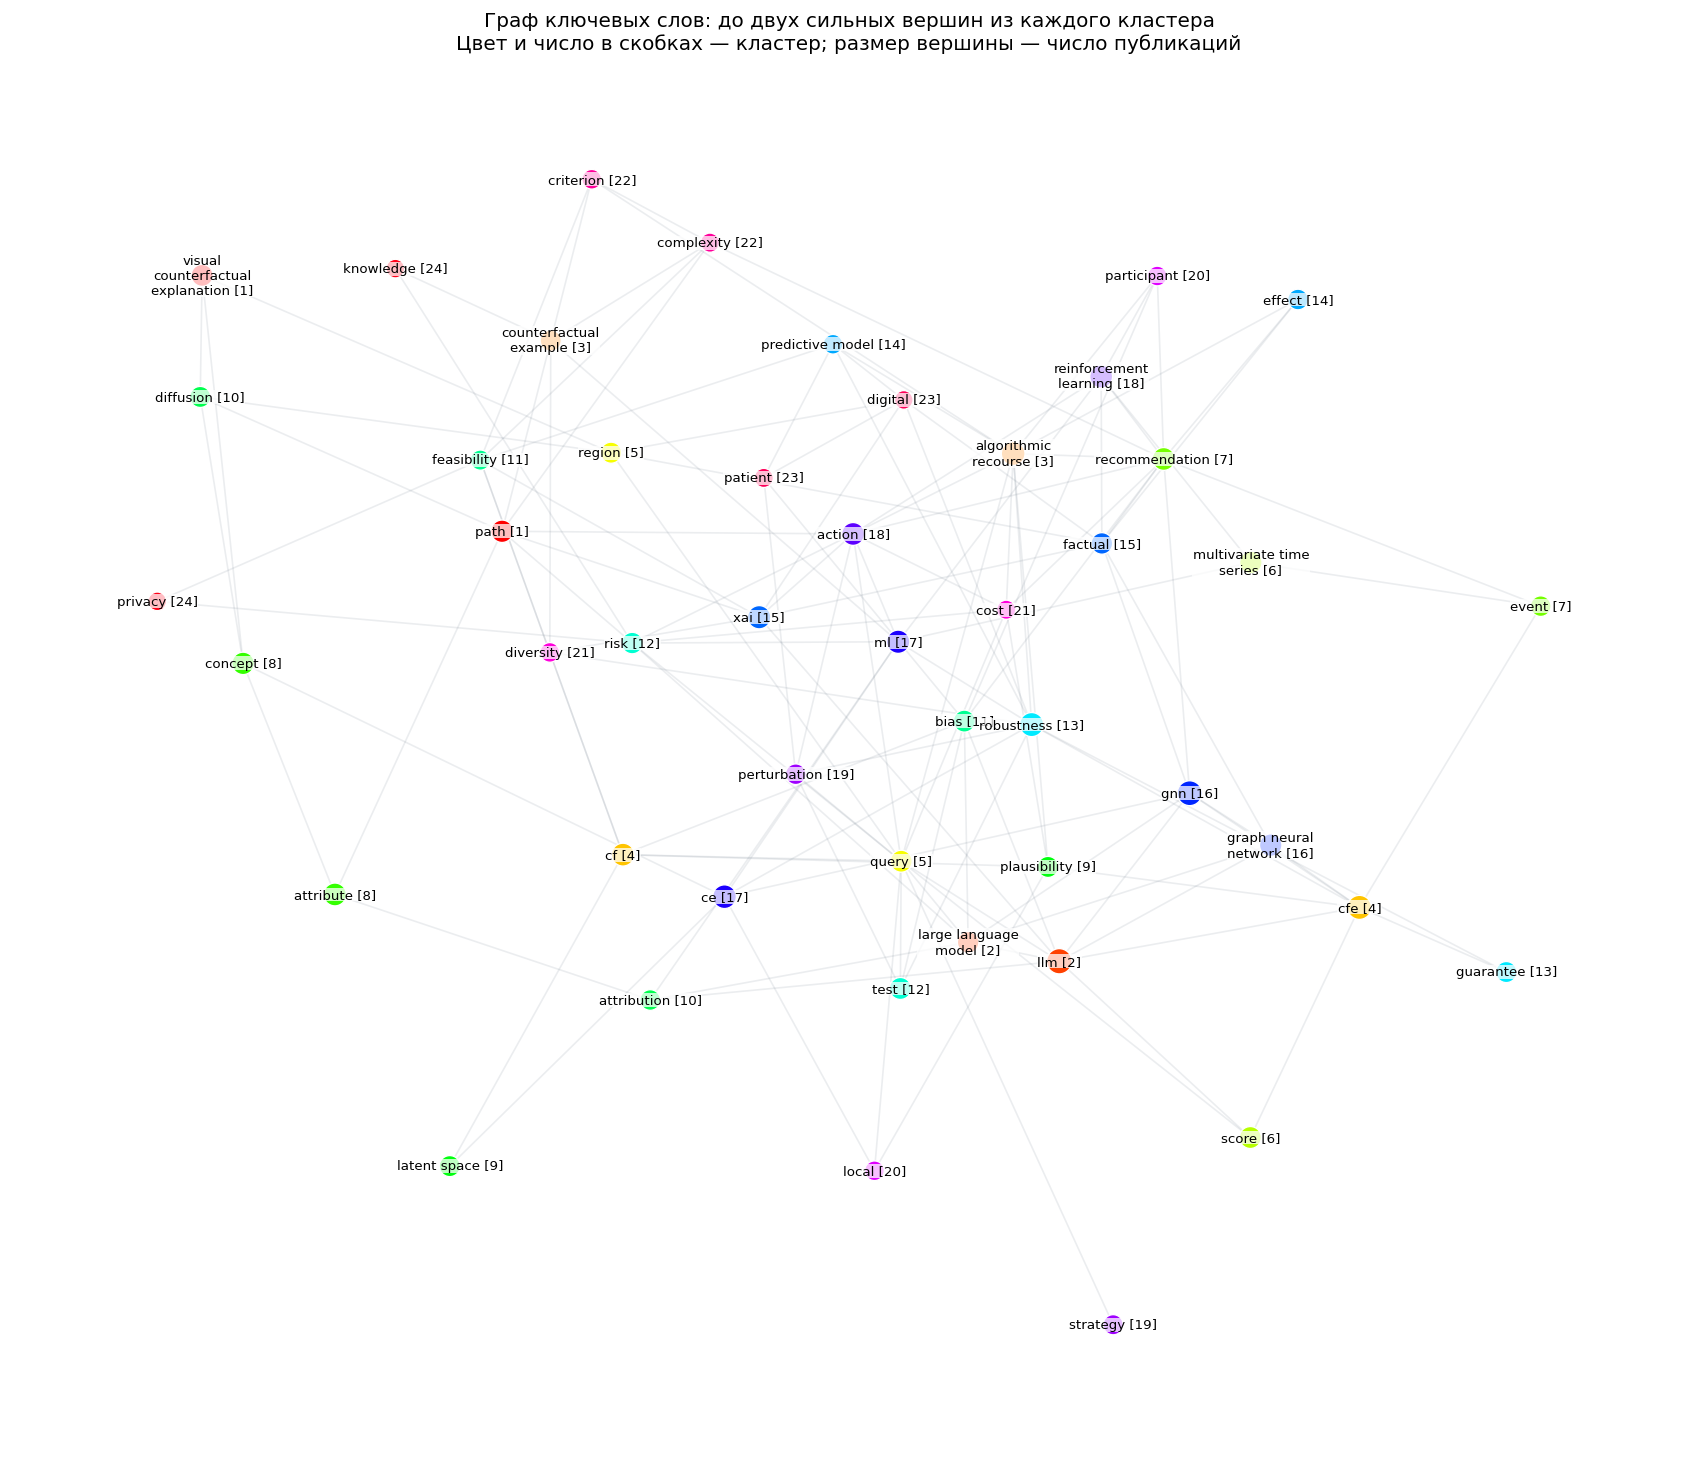

In [13]:
visible = []
for group in communities:
    visible.extend(sorted(group, key=lambda node: (-keyword_graph.degree(node, weight='weight'), node))[:2])
visible = sorted(set(visible))
view = keyword_graph.subgraph(visible).copy()
positions = nx.spring_layout(view, seed=RANDOM_STATE, weight='weight', k=2.0, iterations=300)
cmap = plt.get_cmap('hsv', len(communities))

fig, ax = plt.subplots(figsize=(18, 15))
nx.draw_networkx_edges(view, positions, ax=ax, alpha=0.12, edge_color='#607080')
nx.draw_networkx_nodes(view, positions, ax=ax,
                       node_color=[cmap(partition[node] - 1) for node in view],
                       node_size=[90 + 7 * keyword_counts[node] for node in view],
                       linewidths=0.8, edgecolors='white')
nx.draw_networkx_labels(view, positions, ax=ax,
                        labels={node: fill(labels[node], 19) + f' [{partition[node]}]' for node in view},
                        font_size=8, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2))
ax.set_title('Граф ключевых слов: до двух сильных вершин из каждого кластера\n'
             'Цвет и число в скобках — кластер; размер вершины — число публикаций')
ax.axis('off')
plt.show()

## 7. Центральности — пункт 7

Рассчитываются четыре разных показателя. Для кратчайших путей вес совместной
встречаемости преобразуется в длину $\ell_{ij}=1/w_{ij}$: частая связь становится
короткой. Использовать сам $w_{ij}$ как длину означало бы считать сильные связи
длинными. Все длины положительны.

| Показатель | Что измеряет | Учёт веса |
|:--|:--|:--|
| Degree | Число разных соседей, делённое на $n-1$ | Без весов |
| Betweenness | Долю кратчайших путей, проходящих через слово | Длина $1/w$ |
| Closeness | Обратную среднюю длину пути до других вершин | Длина $1/w$ |
| Eigenvector | Связи со словами, которые сами имеют высокий показатель | Сила связи $w$ |

Betweenness вычисляется точно для всех вершин. Eigenvector считается на крупнейшей
компоненте; за её пределами оставляются пропуски. Для closeness используется
поправка NetworkX на размер компоненты. При длинах меньше единицы взвешенная
closeness может превышать единицу; это не вероятность.

,Ключевое слово,Кластер,degree
llm,llm,2,0.05645
gnn,gnn,16,0.05117
robustness,robustness,13,0.05006
cfe,cfe,4,0.04950
ce,ce,17,0.04727
algorithmic recourse,algorithmic recourse,3,0.04561
xai,xai,15,0.04505


,Ключевое слово,Кластер,betweenness
cfe,cfe,4,0.02474
llm,llm,2,0.02462
ml,ml,17,0.02314
gnn,gnn,16,0.02275
ce,ce,17,0.02247
algorithmic recourse,algorithmic recourse,3,0.02234
action,action,18,0.02162


,Ключевое слово,Кластер,closeness
action,action,18,0.49189
ml,ml,17,0.48326
gnn,gnn,16,0.48054
cfe,cfe,4,0.48002
llm,llm,2,0.47991
algorithmic recourse,algorithmic recourse,3,0.47729
graph neural network,graph neural network,16,0.47599


,Ключевое слово,Кластер,eigenvector
gnn,gnn,16,0.16070
llm,llm,2,0.13711
graph neural network,graph neural network,16,0.13248
action,action,18,0.09959
cfe,cfe,4,0.09817
robustness,robustness,13,0.09356
algorithmic recourse,algorithmic recourse,3,0.08965


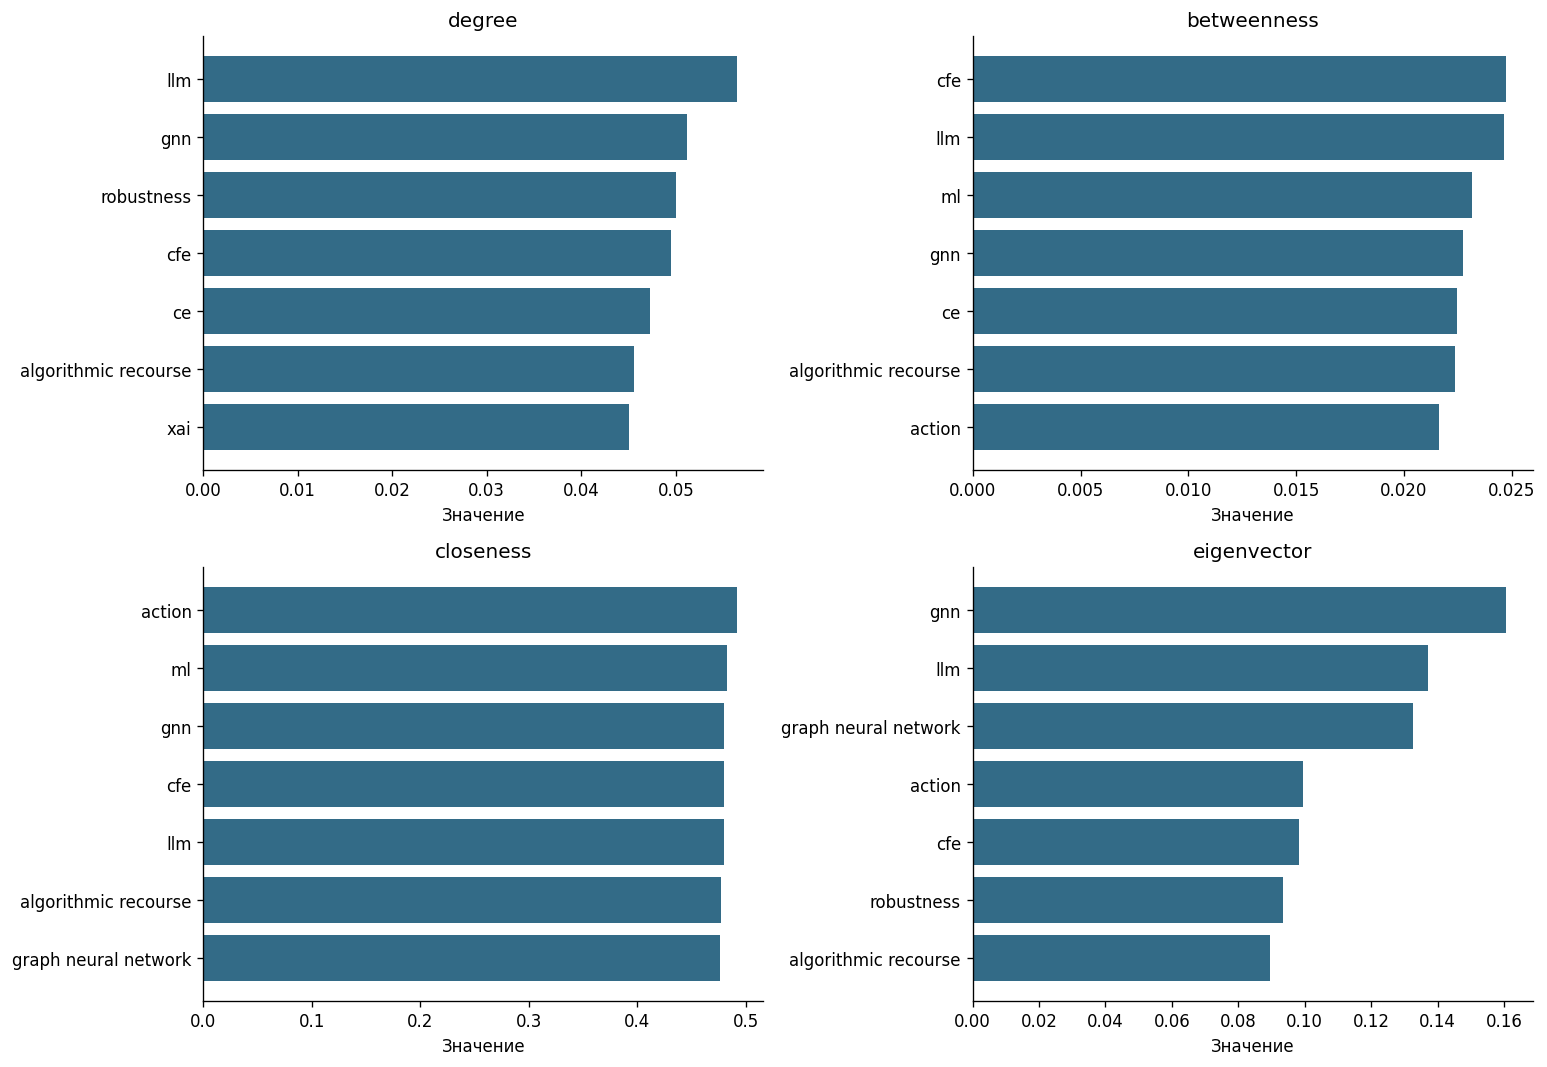

degree: llm (0.05645, кластер 2); gnn (0.05117, кластер 16); robustness (0.05006, кластер 13); cfe (0.04950, кластер 4); ce (0.04727, кластер 17)
betweenness: cfe (0.02474, кластер 4); llm (0.02462, кластер 2); ml (0.02314, кластер 17); gnn (0.02275, кластер 16); ce (0.02247, кластер 17)
closeness: action (0.49189, кластер 18); ml (0.48326, кластер 17); gnn (0.48054, кластер 16); cfe (0.48002, кластер 4); llm (0.47991, кластер 2)
eigenvector: gnn (0.16070, кластер 16); llm (0.13711, кластер 2); graph neural network (0.13248, кластер 16); action (0.09959, кластер 18); cfe (0.09817, кластер 4)


In [14]:
centrality = pd.DataFrame({
    'degree': nx.degree_centrality(keyword_graph),
    'betweenness': nx.betweenness_centrality(keyword_graph, weight='distance'),
    'closeness': nx.closeness_centrality(keyword_graph, distance='distance')
})
largest_component = max(nx.connected_components(keyword_graph), key=len)
eigenvector = nx.eigenvector_centrality(keyword_graph.subgraph(largest_component),
                                       weight='weight', max_iter=2000, tol=1e-9)
centrality['eigenvector'] = pd.Series(eigenvector)
centrality['Ключевое слово'] = pd.Series(labels)
centrality['Кластер'] = pd.Series(partition)
measures = ['degree', 'betweenness', 'closeness', 'eigenvector']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for measure, ax in zip(measures, axes.flat):
    top = centrality.nlargest(7, measure)
    display(top[['Ключевое слово', 'Кластер', measure]].round(5))
    top = top.iloc[::-1]
    ax.barh(top['Ключевое слово'], top[measure], color='#336b87')
    ax.set(title=measure, xlabel='Значение')
plt.tight_layout()
plt.show()
for measure in measures:
    top = centrality.nlargest(5, measure)
    print(f"{measure}: " + "; ".join(f"{row['Ключевое слово']} ({row[measure]:.5f}, кластер {row['Кластер']})" for _, row in top.iterrows()))


### Интерпретация центральностей

Точные значения и номера сообществ показаны в четырёх таблицах выше. Degree характеризует широту соседства, betweenness — участие в коротких путях, closeness — близость к остальному графу, eigenvector — связи с влиятельными соседями. Первые пять слов каждого показателя и их **текущие** номера кластеров печатаются ниже, чтобы текст не расходился с таблицами после перезапуска. Высокий показатель не доказывает смысловую близость двух произвольных тем; сокращения (`gnn`, `ce`, `cfe`) требуют осторожной интерпретации.


## 8. Граф публикаций и поиск — пункт 8

Вершина — arXiv ID без версии. Ребро есть при хотя бы одном общем теге.
`common_count` сохраняет число общих тегов. Для поиска используется взвешенный
Jaccard: $w_{ab}=\sum_{t\in K_a\cap K_b}idf(t)/\sum_{t\in K_a\cup K_b}idf(t)$,
где $idf(t)=1+\ln((N+1)/(df(t)+1))$. Редкие теги дают больший вклад,
а нормировка на объединение учитывает размер наборов тегов. Вес находится в (0, 1].

Поиск выполняет взвешенный обход графа: персонализированный PageRank с перезапуском
в исходной статье (`alpha=0.85`). На каждом шаге переход к соседу пропорционален
весу ребра, а с вероятностью 0.15 обход возвращается в исходную вершину.
Поэтому находятся и статьи без прямого общего тега, связанные через другие работы.
В выдаче показаны балл, прямое сходство, общие теги и кратчайший по числу переходов
путь. Путь объясняет достижимость, но не означает прямого совпадения тем.


Публикаций: 761
Связей: 11371
Компонент связности: 1
Изолированных публикаций: 0


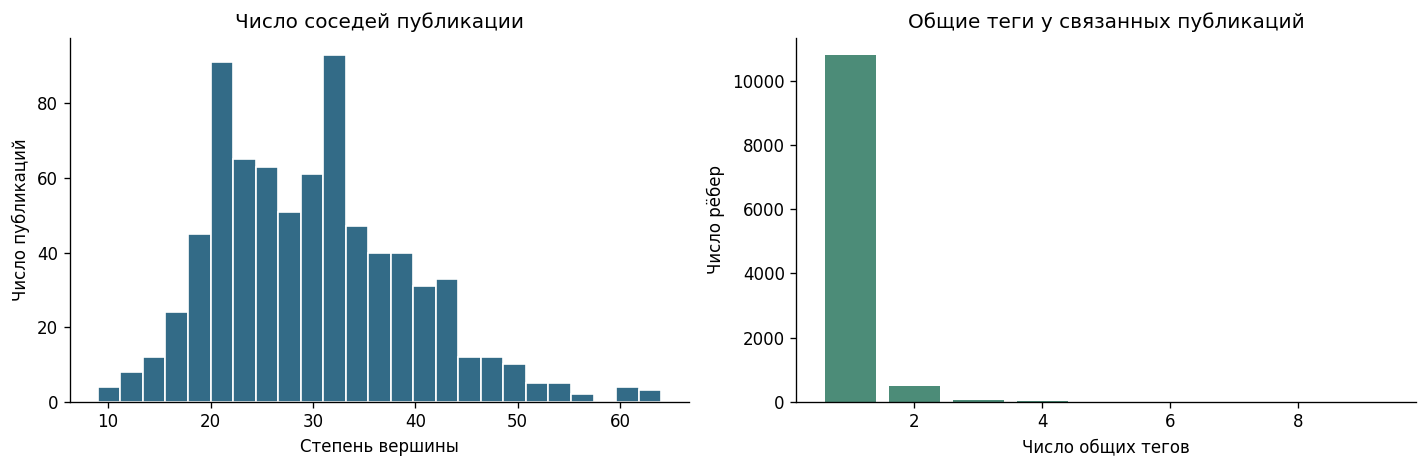

In [15]:
def build_publication_graph(frame):
    graph = nx.Graph()
    inverted = defaultdict(list)
    for row in frame.itertuples():
        graph.add_node(row.id, title=row.title, url=row.url)
        for term in sorted(set(row.keywords)):
            inverted[term].append(row.id)
    tag_sets = {row.id: set(row.keywords) for row in frame.itertuples()}
    idf = {term: 1 + np.log((len(frame) + 1) / (len(ids) + 1))
           for term, ids in inverted.items()}
    for term, paper_ids in inverted.items():
        for left, right in combinations(paper_ids, 2):
            if not graph.has_edge(left, right):
                graph.add_edge(left, right, common_count=0, common_keywords=[])
            graph[left][right]['common_count'] += 1
            graph[left][right]['common_keywords'].append(term)
    for left, right, edge in graph.edges(data=True):
        edge['common_keywords'].sort()
        edge['weight'] = sum(idf[t] for t in edge['common_keywords']) / sum(
            idf[t] for t in tag_sets[left] | tag_sets[right])
    return graph

publication_graph = build_publication_graph(corpus)
papers = corpus.set_index('id')
paper_tags = papers['keywords'].map(set).to_dict()
print('Публикаций:', publication_graph.number_of_nodes())
print('Связей:', publication_graph.number_of_edges())
print('Компонент связности:', nx.number_connected_components(publication_graph))
print('Изолированных публикаций:', nx.number_of_isolates(publication_graph))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([degree for node, degree in publication_graph.degree()], bins=25,
             color='#336b87', edgecolor='white')
axes[0].set(title='Число соседей публикации', xlabel='Степень вершины', ylabel='Число публикаций')
weight_counts = Counter(edge['common_count'] for a, b, edge in publication_graph.edges(data=True))
axes[1].bar(sorted(weight_counts), [weight_counts[k] for k in sorted(weight_counts)], color='#4c8c78')
axes[1].set(title='Общие теги у связанных публикаций', xlabel='Число общих тегов', ylabel='Число рёбер')
plt.tight_layout()
plt.show()

In [16]:
def find_publications(query):
    query = str(query).strip()
    mask = corpus['id'].eq(query) | corpus['title'].str.contains(query, case=False, regex=False)
    return corpus.loc[mask, ['id', 'title', 'published', 'url']].reset_index(drop=True)

def resolve_publication(query):
    query = str(query).strip()
    if not query:
        raise ValueError('Введите arXiv ID или часть названия.')
    if query in publication_graph:
        return query
    matches = find_publications(query)
    if len(matches) == 0:
        raise ValueError('Публикация не найдена в корпусе.')
    if len(matches) > 1:
        display(matches)
        raise ValueError('Найдено несколько статей. Укажите ID из таблицы.')
    return matches.iloc[0]['id']

def similar_publications(paper_id, top_n=5, graph=None):
    graph = publication_graph if graph is None else graph
    if paper_id not in graph:
        raise KeyError(f'В графе нет публикации {paper_id}.')
    if isinstance(top_n, bool) or not isinstance(top_n, (int, np.integer)) or top_n <= 0:
        raise ValueError('top_n должен быть положительным целым числом.')
    component = nx.node_connected_component(graph, paper_id)
    if len(component) == 1:
        return pd.DataFrame(columns=['id', 'title', 'score', 'weight', 'common_count', 'common_keywords', 'path', 'url'])
    view = graph.subgraph(component)
    scores = nx.pagerank(view, alpha=0.85, personalization={paper_id: 1.0},
                         weight='weight', tol=1e-12, max_iter=1000)
    paths = nx.single_source_shortest_path(view, paper_id)
    ranked = sorted((node for node in view if node != paper_id),
                    key=lambda node: (-scores[node], node))
    rows = []
    for other in ranked[:top_n]:
        edge = graph.get_edge_data(paper_id, other, default={})
        rows.append({'id': other, 'title': graph.nodes[other]['title'],
                     'score': scores[other], 'weight': edge.get('weight', 0.0),
                     'common_count': edge.get('common_count', 0),
                     'common_keywords': edge.get('common_keywords', []).copy(),
                     'path': paths[other], 'url': graph.nodes[other]['url']})
    return pd.DataFrame(rows)

def show_recommendations(paper_id, top_n=5):
    print('Исходная статья:', papers.at[paper_id, 'title'])
    print('Ссылка:', papers.at[paper_id, 'url'])
    print('Теги:', ', '.join(labels[tag] for tag in papers.at[paper_id, 'keywords']))
    result = similar_publications(paper_id, top_n)
    table = result.copy()
    table['common_keywords'] = table['common_keywords'].map(lambda tags: ', '.join(labels[t] for t in tags))
    with pd.option_context('display.max_colwidth', None):
        display(table.rename(columns={'score': 'PageRank', 'weight': 'Взвешенный Jaccard', 'common_count': 'Общих тегов', 'common_keywords': 'Общие теги', 'path': 'Путь'}))
    return result

### Поиск для выбранной пользователем статьи

В следующей ячейке можно изменить `PUBLICATION`: указать arXiv ID из корпуса
или однозначную часть названия. `TOP_N` задаёт число рекомендаций. Для просмотра
доступных работ можно выполнить `find_publications('graph')`.
По умолчанию выбран пример про выполнимые контрфактические объяснения.

Исходная статья: FCx: An algorithm for finding Feasible Counterfactual Explanations
Ссылка: https://arxiv.org/abs/2609.19383
Теги: guaranteeing, feasible counterfactual explanation, cf, low cost, feasibility, absolute, efficiently generate, lof, enforces, explanation identify, inferred, job


,id,title,PageRank,Взвешенный Jaccard,Общих тегов,Общие теги,Путь,url
0,2606.18418,P$^2$CE: Model-Agnostic Plausible Pareto-Optimal Counterfactual Explanations,0.009155,0.086807,2,"feasibility, job","[2609.19383, 2606.18418]",https://arxiv.org/abs/2606.18418
1,2504.13899,Predicting Satisfaction of Counterfactual Explanations from Human Ratings of Explanatory Qualities,0.005745,0.038779,1,feasibility,"[2609.19383, 2504.13899]",https://arxiv.org/abs/2504.13899
2,2510.22911,Towards Personalized Treatment Plan: Geometrical Model-Agnostic Approach to Counterfactual Explanations,0.005620,0.044641,1,feasible counterfactual explanation,"[2609.19383, 2510.22911]",https://arxiv.org/abs/2510.22911
3,2410.10463,TABCF: Counterfactual Explanations for Tabular Data Using a Transformer-Based VAE,0.005618,0.035105,1,cf,"[2609.19383, 2410.10463]",https://arxiv.org/abs/2410.10463
4,2510.16637,A Versatile Framework for Designing Group-Sparse Adversarial Attacks,0.005547,0.044625,1,absolute,"[2609.19383, 2510.16637]",https://arxiv.org/abs/2510.16637


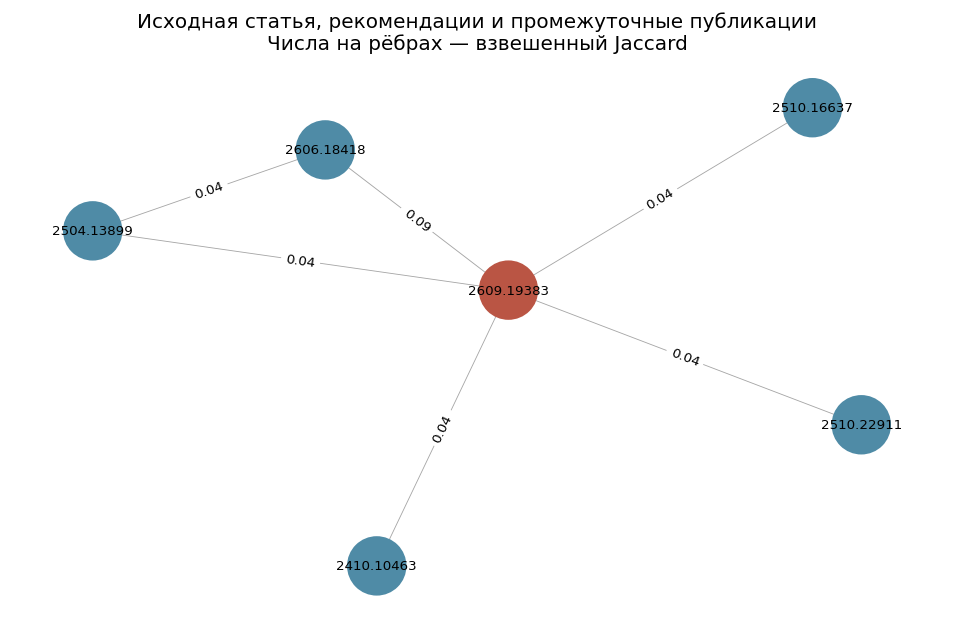

In [17]:
PUBLICATION = '2609.19383'
TOP_N = 5

selected_id = resolve_publication(PUBLICATION)
recommendations = show_recommendations(selected_id, TOP_N)

neighbour_ids = recommendations['id'].tolist()
path_nodes = {node for path in recommendations['path'] for node in path}
local_graph = publication_graph.subgraph(path_nodes).copy()
positions = nx.spring_layout(local_graph, seed=RANDOM_STATE, weight='weight')
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(local_graph, positions, ax=ax, alpha=0.35,
                       width=[0.5 + edge['weight'] / 2 for a, b, edge in local_graph.edges(data=True)])
nx.draw_networkx_nodes(local_graph, positions, ax=ax,
                       node_color=['#ba5544' if node == selected_id else '#4f8ba6' for node in local_graph],
                       node_size=1200)
nx.draw_networkx_labels(local_graph, positions, ax=ax, font_size=8,
                        labels={node: node for node in local_graph})
nx.draw_networkx_edge_labels(local_graph, positions, ax=ax,
                             edge_labels={(a, b): round(e['weight'], 2)
                                          for a, b, e in local_graph.edges(data=True)}, font_size=8)
ax.set_title('Исходная статья, рекомендации и промежуточные публикации\n'
             'Числа на рёбрах — взвешенный Jaccard')
ax.axis('off')
plt.show()

## 9. Проверка поиска — пункт 9

Проверяются взвешенный Jaccard, отсутствие пропущенных рёбер, изолированная
вершина, ошибочный ID и top_n. На цепочке A–B–C проверяется, что обход находит
C без общего тега с A. Для корпуса проверяются пути и порядок баллов.


In [18]:
toy = pd.DataFrame([
    {'id': 'A', 'title': 'Source', 'url': 'A', 'keywords': ['x', 'x']},
    {'id': 'B', 'title': 'Bridge', 'url': 'B', 'keywords': ['x', 'y']},
    {'id': 'C', 'title': 'Indirect', 'url': 'C', 'keywords': ['y']},
    {'id': 'D', 'title': 'Isolated', 'url': 'D', 'keywords': ['z']}
])
toy_graph = build_publication_graph(toy)
assert np.isclose(toy_graph['A']['B']['weight'], 0.5)
assert toy_graph['A']['B']['common_count'] == 1
assert not toy_graph.has_edge('A', 'C')
toy_result = similar_publications('A', 10, graph=toy_graph)
assert toy_result['id'].tolist() == ['B', 'C']
assert toy_result.iloc[1]['path'] == ['A', 'B', 'C']
assert toy_result.iloc[1]['common_count'] == 0
assert similar_publications('D', graph=toy_graph).empty

tag_df = Counter(t for tags in paper_tags.values() for t in tags)
check_idf = {t: 1 + np.log((len(paper_tags) + 1) / (count + 1)) for t, count in tag_df.items()}
for left, right in combinations(paper_tags, 2):
    common = paper_tags[left] & paper_tags[right]
    assert publication_graph.has_edge(left, right) == bool(common)
    if common:
        edge = publication_graph[left][right]
        expected = sum(check_idf[t] for t in common) / sum(check_idf[t] for t in paper_tags[left] | paper_tags[right])
        assert edge['common_count'] == len(common)
        assert set(edge['common_keywords']) == common
        assert np.isclose(edge['weight'], expected)

for source in case_ids if 'case_ids' in globals() else [selected_id, corpus.iloc[0]['id']]:
    result = similar_publications(source, 10)
    assert result['score'].is_monotonic_decreasing
    assert source not in set(result['id']) and result['id'].is_unique
    for row in result.itertuples():
        assert row.path[0] == source and row.path[-1] == row.id
        assert all(publication_graph.has_edge(a, b) for a, b in zip(row.path, row.path[1:]))
        assert row.score > 0
for bad_top_n in (0, -1, 1.5, True):
    try:
        similar_publications(selected_id, bad_top_n)
    except ValueError:
        pass
    else:
        raise AssertionError('Не проверяется top_n.')
try:
    similar_publications('unknown-id')
except KeyError:
    pass
else:
    raise AssertionError('Не проверяется существование публикации.')
assert resolve_publication(papers.at[selected_id, 'title']) == selected_id
assert nx.number_of_selfloops(publication_graph) == 0
print('Тесты пройдены: веса всех пар корпуса, обход через промежуточную вершину, пути и ошибки ввода.')


Тесты пройдены: веса всех пар корпуса, обход через промежуточную вершину, пути и ошибки ввода.


### Содержательная проверка рекомендаций

Тесты выше подтверждают корректность графа, весов и обхода. Они не измеряют смысловую
близость статей. Для неё отдельно рассматриваются три запроса из разных направлений:
выполнимость изменений, объяснения графовых моделей и процедурная справедливость кредитных решений.

In [19]:
case_ids = [
    '2609.19383',
    corpus.loc[corpus['title'].str.contains('graph neural', case=False, regex=False), 'id'].iloc[0],
    corpus.loc[corpus['title'].str.contains('fair', case=False, regex=False), 'id'].iloc[0]
]
case_results = {}
for paper_id in case_ids:
    case_results[paper_id] = show_recommendations(paper_id, 5)

Исходная статья: FCx: An algorithm for finding Feasible Counterfactual Explanations
Ссылка: https://arxiv.org/abs/2609.19383
Теги: guaranteeing, feasible counterfactual explanation, cf, low cost, feasibility, absolute, efficiently generate, lof, enforces, explanation identify, inferred, job


,id,title,PageRank,Взвешенный Jaccard,Общих тегов,Общие теги,Путь,url
0,2606.18418,P$^2$CE: Model-Agnostic Plausible Pareto-Optimal Counterfactual Explanations,0.009155,0.086807,2,"feasibility, job","[2609.19383, 2606.18418]",https://arxiv.org/abs/2606.18418
1,2504.13899,Predicting Satisfaction of Counterfactual Explanations from Human Ratings of Explanatory Qualities,0.005745,0.038779,1,feasibility,"[2609.19383, 2504.13899]",https://arxiv.org/abs/2504.13899
2,2510.22911,Towards Personalized Treatment Plan: Geometrical Model-Agnostic Approach to Counterfactual Explanations,0.005620,0.044641,1,feasible counterfactual explanation,"[2609.19383, 2510.22911]",https://arxiv.org/abs/2510.22911
3,2410.10463,TABCF: Counterfactual Explanations for Tabular Data Using a Transformer-Based VAE,0.005618,0.035105,1,cf,"[2609.19383, 2410.10463]",https://arxiv.org/abs/2410.10463
4,2510.16637,A Versatile Framework for Designing Group-Sparse Adversarial Attacks,0.005547,0.044625,1,absolute,"[2609.19383, 2510.16637]",https://arxiv.org/abs/2510.16637


Исходная статья: A Comparative Study of Counterfactual Explainers for Graph Neural Networks Enabling Multiple Types of Graph Edit
Ссылка: https://arxiv.org/abs/2609.05113
Теги: counterfactual explainer, graph edit, modification required, node classification, predefined output, sota, covering, graph structured data, weakness, adding, diverse set, fall short


,id,title,PageRank,Взвешенный Jaccard,Общих тегов,Общие теги,Путь,url
0,2403.06514,Structure Your Data: Towards Semantic Graph Counterfactuals,0.015692,0.093132,2,"graph edit, sota","[2609.05113, 2403.06514]",https://arxiv.org/abs/2403.06514
1,2402.06030,Game-theoretic Counterfactual Explanation for Graph Neural Networks,0.009437,0.044046,1,node classification,"[2609.05113, 2402.06030]",https://arxiv.org/abs/2402.06030
2,2602.05861,CFRecs: Counterfactual Recommendations on Real Estate User Listing Interaction Graphs,0.009307,0.043852,1,graph structured data,"[2609.05113, 2602.05861]",https://arxiv.org/abs/2602.05861
3,2602.06240,ATEX-CF: Attack-Informed Counterfactual Explanations for Graph Neural Networks,0.009196,0.043687,1,node classification,"[2609.05113, 2602.06240]",https://arxiv.org/abs/2602.06240
4,2210.11695,Global Counterfactual Explainer for Graph Neural Networks,0.008189,0.039504,1,counterfactual explainer,"[2609.05113, 2210.11695]",https://arxiv.org/abs/2210.11695


Исходная статья: Do Fair Models Reason Fairly? Counterfactual Explanation Consistency for Procedural Fairness in Credit Decisions
Ссылка: https://arxiv.org/abs/2605.12701
Теги: procedural, fairness metric, fair, hidden, consistency, bias, reasoning, data demonstrate, individual level, mortgage, nearest neighbor counterfactual, outcome


,id,title,PageRank,Взвешенный Jaccard,Общих тегов,Общие теги,Путь,url
0,2412.17523,Constructing Fair Latent Space for Intersection of Fairness and Explainability,0.010102,0.090421,2,"fair, fairness metric","[2605.12701, 2412.17523]",https://arxiv.org/abs/2412.17523
1,2404.15687,Graph Neural Networks for Vulnerability Detection: A Counterfactual Explanation,0.006497,0.042900,1,reasoning,"[2605.12701, 2404.15687]",https://arxiv.org/abs/2404.15687
2,2002.08247,Learning Global Transparent Models Consistent with Local Contrastive Explanations,0.005848,0.040460,1,consistency,"[2605.12701, 2002.08247]",https://arxiv.org/abs/2002.08247
3,2602.10457,Analyzing Fairness of Neural Network Prediction via Counterfactual Dataset Generation,0.005737,0.036371,1,bias,"[2605.12701, 2602.10457]",https://arxiv.org/abs/2602.10457
4,2211.14858,"""Explain it in the Same Way!"" -- Model-Agnostic Group Fairness of Counterfactual Explanations",0.005683,0.046227,1,outcome,"[2605.12701, 2211.14858]",https://arxiv.org/abs/2211.14858


### Интерпретация поиска

Для *FCx: An algorithm for finding Feasible Counterfactual Explanations* первый результат — *P$^2$CE: Model-Agnostic Plausible Pareto-Optimal Counterfactual Explanations*: **PageRank = 0.009155**, **взвешенный Jaccard = 0.086807**, **общих тегов — 2**. Теги: `feasibility, job`. Путь: 2609.19383 → 2606.18418.

Первые пять результатов имеют прямую связь с запросом. Возможность непрямого поиска отдельно подтверждена тестом A–B–C.

Для *A Comparative Study of Counterfactual Explainers for Graph Neural Networks Enabling Multiple Types of Graph Edit* первый результат — *Structure Your Data: Towards Semantic Graph Counterfactuals*: **PageRank = 0.015692**, **взвешенный Jaccard = 0.093132**, **общих тегов — 2**. Теги: `graph edit, sota`. Путь: 2609.05113 → 2403.06514.

Первые пять результатов имеют прямую связь с запросом. Возможность непрямого поиска отдельно подтверждена тестом A–B–C.

Для *Do Fair Models Reason Fairly? Counterfactual Explanation Consistency for Procedural Fairness in Credit Decisions* первый результат — *Constructing Fair Latent Space for Intersection of Fairness and Explainability*: **PageRank = 0.010102**, **взвешенный Jaccard = 0.090421**, **общих тегов — 2**. Теги: `fair, fairness metric`. Путь: 2605.12701 → 2412.17523.

Первые пять результатов имеют прямую связь с запросом. Возможность непрямого поиска отдельно подтверждена тестом A–B–C.

Взвешенный Jaccard описывает прямое пересечение с учётом редкости тегов. Персонализированный PageRank учитывает вероятности переходов и возврат к исходной статье, поэтому порядок не обязан совпадать с прямым сходством. Показанный кратчайший по числу переходов путь подтверждает достижимость, а не объясняет весь балл PageRank. Общие неспецифичные теги могут давать слабые рекомендации; эти три примера — качественная проверка, без утверждения о precision или recall.

## Итоговые выводы

Корпус содержит **761** уникальную публикацию с 2020-01-21 по 2026-09-17; исходных записей — 766. Проверены тема, даты и обязательные поля. Анализируются названия и аннотации.

Ципф: на рангах 10–1000 наклон -0.936, R²=0.995; на всём словаре наклон -1.371, R²=0.964. Хипс: β=0.476–0.517. Распределения согласуются с ожидаемой формой; это описательная проверка, а не доказательство законов.

WordNet нормализует существительные; специальные термины и сокращения проверены отдельными примерами. Объяснено ручное расширение стоп-слов. TF-IDF выбирает до 12 униграмм, биграмм и триграмм на статью.

Граф ключевых слов содержит **3597** вершин. При `seed=42` получено **24 сообщества** с модульностью **0.3646**. Их состав интерпретирован по тегам и статьям; смешанные сообщества отмечены отдельно. Проверена чувствительность к seed и порогам веса. Четыре центральности рассчитаны и интерпретированы отдельно.

Граф публикаций содержит **761** вершин и **11371** рёбер. Веса — IDF-взвешенный Jaccard; число общих тегов также сохраняется. Персонализированный PageRank находит прямых и непрямых соседей. Проверены веса и наличие рёбер для всех пар корпуса, цепочка A–B–C, пути, порядок выдачи и ошибки ввода; рассмотрены три содержательных запроса.

Ограничения: выборка зависит от фраз запроса arXiv; нормализация существительных не объединяет все глагольные формы, синонимы и полные названия сокращений. Статистические n-граммы могут быть нетематическими; границы Louvain зависят от seed. PageRank учитывает связность, поэтому высокий балл не гарантирует смысловой релевантности. Без экспертной разметки тесты подтверждают алгоритм, а не точность рекомендаций.
